In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Food delivery.csv")

In [3]:
df.head()


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [4]:
df.shape

(45593, 20)

In [5]:
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [7]:
type(df["Delivery_person_Age"][0])

str

In [8]:
df["Weatherconditions"].value_counts()

Weatherconditions
conditions Fog           7654
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
conditions Sunny         7284
conditions NaN            616
Name: count, dtype: int64

In [9]:
temp = "conditions Fog"
temp.split(" ")[1]

'Fog'

In [10]:
df["Weatherconditions"] = df["Weatherconditions"].apply(lambda temp:temp.split(" ")[1] if pd.notnull(temp) else temp)

In [11]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [12]:
df.select_dtypes("object").columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival',
       'City', 'Time_taken(min)'],
      dtype='object')

In [13]:
for col in df.select_dtypes("object").columns:
    df[col] = df[col].str.strip()
    df[col] = df[col].replace("NaN",np.nan)
    

In [14]:
df[df["Delivery_person_Age"] == "conditions NaN"]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)


In [15]:
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions               616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [16]:
df["Time_taken(min)"] = df["Time_taken(min)"].apply(lambda temp:int(temp.split(" ")[1]) if pd.notnull(temp) else temp)

In [17]:
for col in ['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries']:
    df[col] =pd.to_numeric(df[col],errors = "coerce")

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          43739 non-null  float64
 3   Delivery_person_Ratings      43685 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            44977 non-null  object 
 12  Road_traffic_density         44992 non-null  object 
 13  Vehicle_conditio

In [19]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min)
count,43739.000000,43685.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,44600.000000,45593.000000
mean,29.567137,4.633780,17.017729,70.231332,17.465186,70.845702,1.023359,0.744664,26.294607
std,5.815155,0.334716,8.185109,22.883647,7.335122,21.118812,0.839065,0.572473,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.546947,75.898497,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


In [20]:
df[df["Delivery_person_Ratings"]>5]["Delivery_person_Ratings"].shape

(53,)

In [21]:
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].clip(upper=5)

In [22]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min)
count,43739.000000,43685.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,44600.000000,45593.000000
mean,29.567137,4.632567,17.017729,70.231332,17.465186,70.845702,1.023359,0.744664,26.294607
std,5.815155,0.331560,8.185109,22.883647,7.335122,21.118812,0.839065,0.572473,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.546947,75.898497,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          43739 non-null  float64
 3   Delivery_person_Ratings      43685 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            44977 non-null  object 
 12  Road_traffic_density         44992 non-null  object 
 13  Vehicle_conditio

In [24]:
for col in ["Delivery_person_Age","Delivery_person_Ratings","multiple_deliveries"]:
    df[col]= df[col].fillna(df[col].median())

In [25]:
for col in ["Road_traffic_density","Weatherconditions","Festival","City"]:
    df[col]= df[col].fillna(df[col].mode()[0])
    #df[col].fillna(df[col].mode()[0],inplcae =True)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

## EDA

In [27]:
df["Time_taken(min)"].describe()

count    45593.000000
mean        26.294607
std          9.383806
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

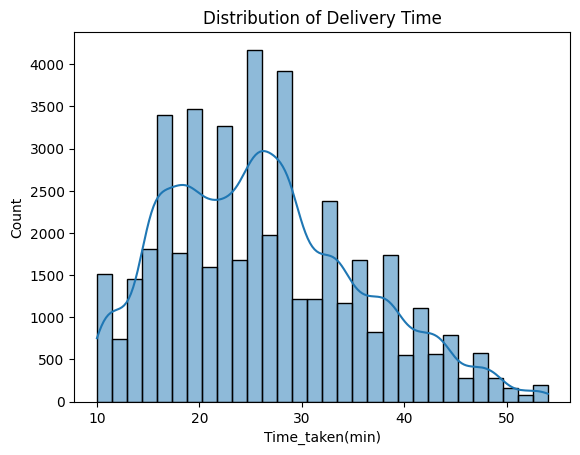

In [28]:
sns.histplot(df["Time_taken(min)"],bins=30,kde = True)
plt.title("Distribution of Delivery Time")
plt.show()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [30]:
df["Road_traffic_density"].value_counts()

Road_traffic_density
Low       16078
Jam       14143
Medium    10947
High       4425
Name: count, dtype: int64

In [31]:
df.groupby("Road_traffic_density")["Time_taken(min)"].agg(["count","mean","median","std"])

,count,mean,median,std
Road_traffic_density,,,,
High,4425,27.240000,27.0,8.396012
Jam,14143,31.176624,31.0,9.940904
Low,16078,21.464175,21.0,6.988438
Medium,10947,26.699644,27.0,8.560179


In [32]:
df["Weatherconditions"].value_counts()

Weatherconditions
Fog           8270
Stormy        7586
Cloudy        7536
Sandstorms    7495
Windy         7422
Sunny         7284
Name: count, dtype: int64

In [33]:
df.groupby("Weatherconditions")["Time_taken(min)"].agg(["count","mean","median","std"])

,count,mean,median,std
Weatherconditions,,,,
Cloudy,7536,28.917330,28.0,10.084352
Fog,8270,28.739541,28.0,10.100816
Sandstorms,7495,25.875517,26.0,8.618434
Stormy,7586,25.870815,26.0,8.473273
Sunny,7284,21.856947,20.0,8.327210
Windy,7422,26.118836,26.0,8.615702


In [34]:
df["Festival"].value_counts()

Festival
No     44697
Yes      896
Name: count, dtype: int64

In [35]:
df.groupby("Festival")["Time_taken(min)"].agg(["count","mean","median","std"])

,count,mean,median,std
Festival,,,,
No,44697,25.909256,25.0,9.052291
Yes,896,45.517857,45.0,4.001915


In [36]:
df["City"].value_counts()

City
Metropolitian    35293
Urban            10136
Semi-Urban         164
Name: count, dtype: int64

In [37]:
df.groupby("City")["Time_taken(min)"].agg(["count","mean","median","std"])

,count,mean,median,std
City,,,,
Metropolitian,35293,27.136486,26.0,9.205358
Semi-Urban,164,49.731707,49.0,2.693089
Urban,10136,22.984017,22.0,8.866011


In [38]:
df["Delivery_person_Age"].describe()

count    45593.000000
mean        29.584739
std          5.696333
min         15.000000
25%         25.000000
50%         30.000000
75%         34.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

<Axes: xlabel='Delivery_person_Age', ylabel='Count'>

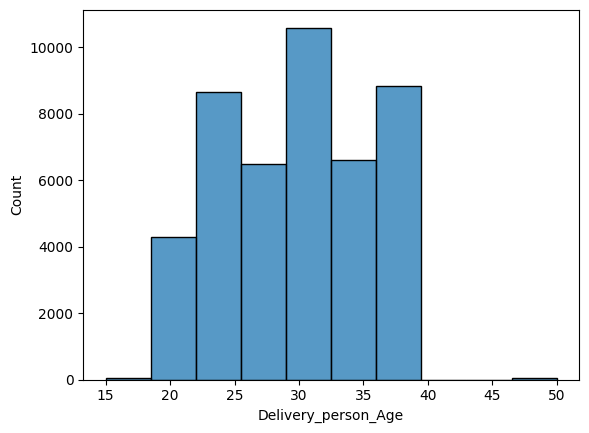

In [39]:
sns.histplot(df["Delivery_person_Age"],bins =10)

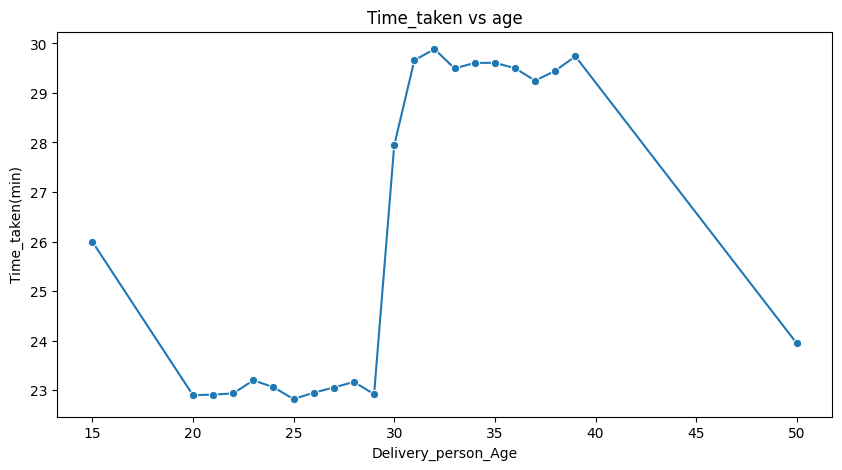

In [40]:
plt.figure(figsize = (10,5))

sns.lineplot(
    data =df,
    x = "Delivery_person_Age",
    y = "Time_taken(min)",
    estimator = "mean",
    errorbar = None,
    marker = "o"
)
plt.title("Time_taken vs age")
plt.show()

In [41]:
df["Delivery_person_Ratings"].describe()

count    45593.000000
mean         4.635389
std          0.324828
min          1.000000
25%          4.600000
50%          4.700000
75%          4.800000
max          5.000000
Name: Delivery_person_Ratings, dtype: float64

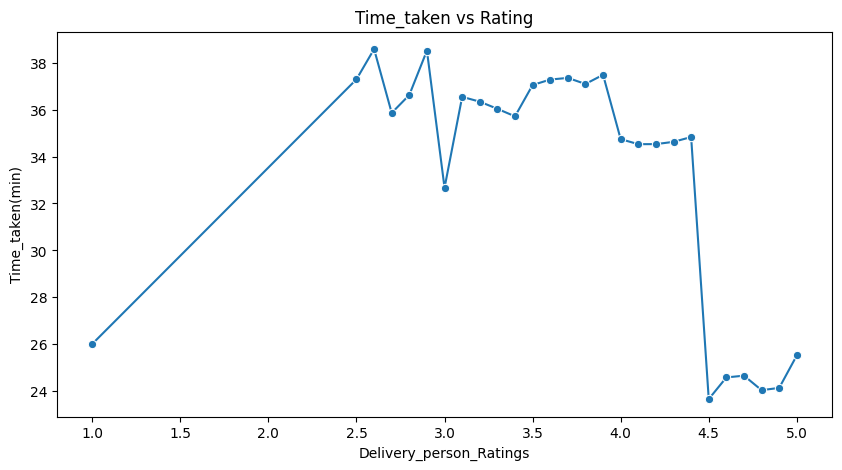

In [42]:
plt.figure(figsize = (10,5))

sns.lineplot(
    data =df,
    x = "Delivery_person_Ratings",
    y = "Time_taken(min)",
    estimator = "mean",
    errorbar = None,
    marker = "o"
)
plt.title("Time_taken vs Rating")
plt.show()

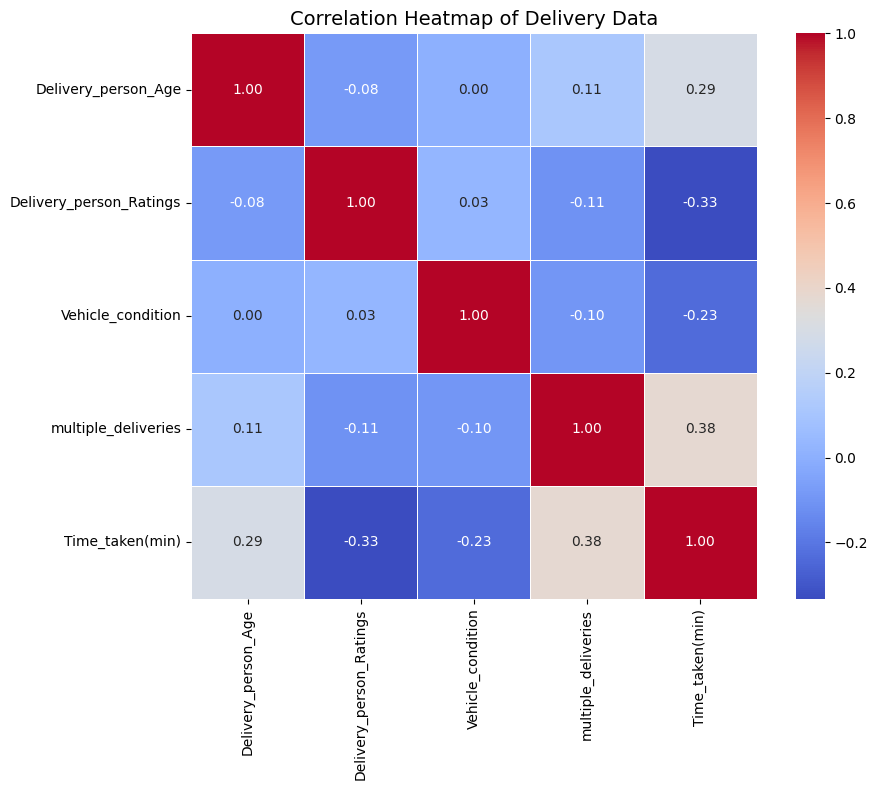

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select numeric features or compute correlation matrix
numeric_df = df.select_dtypes(include=["float64", "int64"])
cols_to_drop = [
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
]
# 2. Set up the figure size
plt.figure(figsize=(10, 8))

# 3. Create the heatmap
sns.heatmap(
        numeric_df.drop(columns=cols_to_drop, errors="ignore").corr(),
    annot=True,  # Displays correlation values inside cells
    fmt=".2f",  # Formats numbers to 2 decimal places
    cmap="coolwarm",  # Color palette (e.g., 'vlag', 'coolwarm', 'viridis')
    linewidths=0.5,  # Space between cells
    square=True,
)

# 4. Add title and render
plt.title("Correlation Heatmap of Delivery Data", fontsize=14)
plt.tight_layout()
plt.show()

In [44]:
df["Time_Orderd"]

0        11:30:00
1        19:45:00
2        08:30:00
3        18:00:00
4        13:30:00
           ...   
45588    11:35:00
45589    19:55:00
45590    23:50:00
45591    13:35:00
45592    17:10:00
Name: Time_Orderd, Length: 45593, dtype: object

In [45]:
hour = pd.to_datetime(df["Time_Orderd"],format ="%H:%M:%S",errors = "coerce").dt.hour

In [46]:
df.groupby(hour)["Time_taken(min)"].agg(["mean","median"])

,mean,median
Time_Orderd,,
0.0,22.169767,21.0
8.0,19.584158,19.0
9.0,19.543914,19.0
10.0,19.482170,19.0
11.0,26.380734,27.0
12.0,26.826233,27.0
13.0,27.538265,27.0
14.0,27.537295,27.0
15.0,23.194731,23.0


## Feature Engineering

### haversine Formula

In [47]:
import numpy as np


def calculate_series_distance(
    lat1_series, lon1_series, lat2_series, lon2_series, miles=False
):
    """Calculates the great-circle (straight-line) distance between two series of

    lat/lon points using the Haversine formula. Returns distance in km (or
    miles). Turns four raw coordinate columns into one meaningful 'distance'
    feature.
    """
    # Earth radius: 3956 miles or 6371 kilometers
    r = 3956 if miles else 6371

    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(
        np.radians, [lat1_series, lon1_series, lat2_series, lon2_series]
    )

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))

    return c * r

In [48]:
df["Distance"] = calculate_series_distance(df["Restaurant_latitude"],df["Restaurant_longitude"],df["Delivery_location_latitude"],df["Delivery_location_longitude"])

In [49]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24,3.025149
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,20.183530
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26,1.552758
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,7.790401
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30,6.210138


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [51]:
df["Distance"].describe()

count    45593.000000
mean        99.303911
std       1099.731281
min          1.465067
25%          4.663493
50%          9.264281
75%         13.763977
max      19692.674606
Name: Distance, dtype: float64

In [52]:
df[df["Distance"]>100]["Distance"].describe()

count      431.000000
mean      9484.671093
std       6252.618252
min       2216.065794
25%       4434.856783
50%       5897.015762
75%      17132.390571
max      19692.674606
Name: Distance, dtype: float64

In [53]:
df[df["Distance"]<100]["Distance"].describe()

count    45162.000000
mean         9.735396
std          5.608508
min          1.465067
25%          4.663412
50%          9.220209
75%         13.681490
max         20.969489
Name: Distance, dtype: float64

In [54]:
df = df[df["Distance"]<100].reset_index(drop =True)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45162 entries, 0 to 45161
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45162 non-null  object 
 1   Delivery_person_ID           45162 non-null  object 
 2   Delivery_person_Age          45162 non-null  float64
 3   Delivery_person_Ratings      45162 non-null  float64
 4   Restaurant_latitude          45162 non-null  float64
 5   Restaurant_longitude         45162 non-null  float64
 6   Delivery_location_latitude   45162 non-null  float64
 7   Delivery_location_longitude  45162 non-null  float64
 8   Order_Date                   45162 non-null  object 
 9   Time_Orderd                  43706 non-null  object 
 10  Time_Order_picked            45162 non-null  object 
 11  Weatherconditions            45162 non-null  object 
 12  Road_traffic_density         45162 non-null  object 
 13  Vehicle_conditio

In [56]:
df["order_hour"] = pd.to_datetime(df["Time_Orderd"],format ="%H:%M:%S",errors = "coerce").dt.hour

In [57]:
df["order_hour"] = df["order_hour"].fillna(df["order_hour"].median())

In [58]:
len(df["Delivery_person_ID"].unique())

1320

In [59]:
feature = ['Delivery_person_Age','Delivery_person_Ratings','Distance', 'order_hour','Weatherconditions', 'Road_traffic_density',
           'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
           'multiple_deliveries', 'Festival', 'City',]

In [60]:
X = df[feature]

In [61]:
y =df["Time_taken(min)"]

### Encoding

In [62]:
df["Road_traffic_density"].value_counts()

Road_traffic_density
Low       15826
Jam       14050
Medium    10886
High       4400
Name: count, dtype: int64

In [63]:
traffic_mapping ={
    "Low":0,
    "Medium":1,
    "High":2,
    "Jam":3
}
X["Road_traffic_density"] = X["Road_traffic_density"].map(traffic_mapping)

C:\Users\tomar\AppData\Local\Temp\ipykernel_15900\2232355258.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Road_traffic_density"] = X["Road_traffic_density"].map(traffic_mapping)


In [64]:
X["Road_traffic_density"]

0        2
1        3
2        0
3        1
4        2
        ..
45157    2
45158    3
45159    0
45160    2
45161    1
Name: Road_traffic_density, Length: 45162, dtype: int64

In [65]:
df["Weatherconditions"].value_counts()

Weatherconditions
Fog           8071
Stormy        7544
Cloudy        7485
Sandstorms    7442
Windy         7382
Sunny         7238
Name: count, dtype: int64

In [66]:
X=pd.get_dummies(X,columns = ['Type_of_order','Type_of_vehicle','Festival','City','Weatherconditions'],drop_first =True,dtype =int)

## Train/ Test Split

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X_train,X_test,Y_train,y_test = train_test_split(X,y,test_size =0.2,random_state= 42)

In [69]:
X_train.shape,X_test.shape

((36129, 21), (9033, 21))

In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [71]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36129 entries, 24844 to 15795
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Delivery_person_Age               36129 non-null  float64
 1   Delivery_person_Ratings           36129 non-null  float64
 2   Distance                          36129 non-null  float64
 3   order_hour                        36129 non-null  float64
 4   Road_traffic_density              36129 non-null  int64  
 5   Vehicle_condition                 36129 non-null  int64  
 6   multiple_deliveries               36129 non-null  float64
 7   Type_of_order_Drinks              36129 non-null  int32  
 8   Type_of_order_Meal                36129 non-null  int32  
 9   Type_of_order_Snack               36129 non-null  int32  
 10  Type_of_vehicle_electric_scooter  36129 non-null  int32  
 11  Type_of_vehicle_motorcycle        36129 non-null  int32  
 12  Type_

In [72]:
X_train_scaled = scaler.fit_transform(X_train)

In [73]:
X_test_scaled = scaler.transform(X_test)

In [74]:
X_test_scaled

array([[ 1.65374296, -0.11401152,  0.22631349, ..., -0.44643354,
        -0.43645196, -0.44093773],
       [ 1.47792437,  0.82435639, -1.46506334, ..., -0.44643354,
        -0.43645196, -0.44093773],
       [-1.33517305, -1.05237944,  1.26748879, ..., -0.44643354,
        -0.43645196, -0.44093773],
       ...,
       [ 0.77465001,  0.51156709, -0.64288665, ..., -0.44643354,
        -0.43645196, -0.44093773],
       [-0.98353587, -1.36516875,  0.75401218, ..., -0.44643354,
        -0.43645196, -0.44093773],
       [ 1.65374296, -0.11401152,  1.86047019, ..., -0.44643354,
        -0.43645196, -0.44093773]])

In [75]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns,index = X_train.index)

In [76]:
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns,index = X_test.index)

In [77]:
X_train_scaled

,Delivery_person_Age,Delivery_person_Ratings,Distance,order_hour,Road_traffic_density,Vehicle_condition,multiple_deliveries,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,...,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Festival_Yes,City_Semi-Urban,City_Urban,Weatherconditions_Fog,Weatherconditions_Sandstorms,Weatherconditions_Stormy,Weatherconditions_Sunny,Weatherconditions_Windy
24844,-1.335173,0.511567,-0.351713,-0.097037,-0.294111,1.176132,0.440963,-0.576146,-0.577382,-0.581942,...,-1.174084,-0.709751,-0.140460,-0.060093,-0.534408,-0.466578,-0.445586,-0.446434,-0.436452,2.267894
33010,1.126287,0.198778,1.346836,0.745207,1.311985,1.176132,2.199607,1.735670,-0.577382,-0.581942,...,-1.174084,1.408946,7.119459,-0.060093,-0.534408,-0.466578,-0.445586,-0.446434,-0.436452,-0.440938
16599,-0.807717,-0.426801,1.307141,0.745207,1.311985,1.176132,-1.317681,-0.576146,-0.577382,-0.581942,...,0.851728,-0.709751,-0.140460,-0.060093,-0.534408,-0.466578,-0.445586,2.239975,-0.436452,-0.440938
35248,1.477924,0.511567,-1.192912,-1.360402,0.508937,-0.023373,-1.317681,-0.576146,1.731955,-0.581942,...,-1.174084,1.408946,-0.140460,-0.060093,-0.534408,-0.466578,-0.445586,2.239975,-0.436452,-0.440938
14293,-0.631899,1.137146,-1.174340,-1.992085,-1.097159,-1.222879,0.440963,-0.576146,-0.577382,-0.581942,...,0.851728,-0.709751,-0.140460,-0.060093,-0.534408,2.143266,-0.445586,-0.446434,-0.436452,-0.440938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,1.477924,0.824356,-0.904900,0.745207,1.311985,-1.222879,0.440963,-0.576146,-0.577382,1.718384,...,0.851728,-0.709751,-0.140460,-0.060093,-0.534408,-0.466578,-0.445586,-0.446434,-0.436452,2.267894
44732,0.071376,0.198778,1.860470,1.166329,-1.097159,-1.222879,-1.317681,-0.576146,-0.577382,1.718384,...,0.851728,-0.709751,-0.140460,-0.060093,-0.534408,-0.466578,-0.445586,-0.446434,-0.436452,2.267894
38158,1.653743,-0.114012,-0.672842,-0.939280,0.508937,1.176132,0.440963,1.735670,-0.577382,-0.581942,...,0.851728,-0.709751,-0.140460,-0.060093,-0.534408,-0.466578,-0.445586,-0.446434,-0.436452,2.267894
860,0.774650,0.511567,-1.181415,-1.992085,-1.097159,-0.023373,0.440963,-0.576146,-0.577382,1.718384,...,-1.174084,1.408946,-0.140460,-0.060093,-0.534408,2.143266,-0.445586,-0.446434,-0.436452,-0.440938


In [78]:
import joblib

### save filter data

In [79]:
joblib.dump(scaler,"Standard_scaler.pkl")

['Standard_scaler.pkl']

# model training

Model 1 - LINEAR REGRESSION

In [80]:
from sklearn.linear_model import LinearRegression
lr =LinearRegression()

In [81]:
lr.fit(X_train_scaled,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [82]:
lr.coef_

array([ 2.25707747, -2.17742371,  2.08640083, -0.54457378,  2.92036387,
       -1.7354634 ,  1.71928013, -0.07066725, -0.02591592, -0.01696524,
       -0.4410398 , -0.97325398, -1.21548077,  1.33110365,  0.58436762,
       -0.80964671,  0.08306582, -1.00542433, -1.01075931, -2.31276779,
       -0.96904815])

In [83]:
lr.intercept_

26.278723463145948

In [84]:
X_train_scaled.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Distance',
       'order_hour', 'Road_traffic_density', 'Vehicle_condition',
       'multiple_deliveries', 'Type_of_order_Drinks', 'Type_of_order_Meal',
       'Type_of_order_Snack', 'Type_of_vehicle_electric_scooter',
       'Type_of_vehicle_motorcycle', 'Type_of_vehicle_scooter', 'Festival_Yes',
       'City_Semi-Urban', 'City_Urban', 'Weatherconditions_Fog',
       'Weatherconditions_Sandstorms', 'Weatherconditions_Stormy',
       'Weatherconditions_Sunny', 'Weatherconditions_Windy'],
      dtype='object')

In [85]:
from sklearn.metrics import r2_score,mean_squared_error

In [86]:
y_predict_test = lr.predict(X_test_scaled)

In [87]:
rmse_test = np.sqrt(mean_squared_error(y_test,y_predict_test))
rmse_test

6.212510956097219

In [88]:
rmse_trained = np.sqrt(mean_squared_error(Y_train,lr.predict(X_train_scaled)))

In [89]:
r2_test = r2_score(y_test,y_predict_test)

In [90]:
r2_train = r2_score(Y_train,lr.predict(X_train_scaled))
r2_train

0.5833426978406996

In [91]:
print(rmse_trained,r2_test)

6.043532429197743 0.569315466760959


In [92]:
print(rmse_test,r2_test)

6.212510956097219 0.569315466760959


Model2 - Decision Tree

In [93]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor(random_state =42)

In [94]:
dtr.fit(X_train_scaled,Y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [95]:
y_pred_dtr = dtr.predict(X_test_scaled)

In [96]:
#for testing data
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred_dtr)
rmse = np.sqrt(mse)
r2_score_dtr = r2_score(y_test,y_pred_dtr)

print("RMSE_Test_DTR",rmse)
print("R2_score_test_dtr",r2_score_dtr)

RMSE_Test_DTR 5.491587519863505
R2_score_test_dtr 0.663472345116529


In [97]:
y_pred_train = dtr.predict(X_train_scaled)

In [98]:
#training data
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mse=mean_squared_error(Y_train,y_pred_train)
rmse = np.sqrt(mse)
r2_score_dtr = r2_score(Y_train,y_pred_train)

print("RMSE_Train_DTR",rmse)
print("R2_train_dtr",r2_score_dtr)

RMSE_Train_DTR 0.0
R2_train_dtr 1.0


## Random forest

In [99]:
from sklearn.ensemble import RandomForestRegressor

In [100]:
rf = RandomForestRegressor(n_estimators = 100,random_state =42)

In [101]:
rf.fit(X_train_scaled,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [102]:
y_pred_rf = rf.predict(X_test_scaled)

In [103]:
#for testing data
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred_rf)
rmse = np.sqrt(mse)
r2_score_rf = r2_score(y_test,y_pred_rf)

print("RMSE_Test_RF",rmse)
print("R2_score_test_RF",r2_score_rf)

RMSE_Test_RF 4.028700960508738
R2_score_test_RF 0.818884756316947


In [104]:
y_pred_rf_train = rf.predict(X_train_scaled)

In [105]:
#training data
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mse=mean_squared_error(Y_train,y_pred_rf_train)
rmse = np.sqrt(mse)
r2_score_RF = r2_score(Y_train,y_pred_rf_train)
print("RMSE_Train_RF",rmse)
print("R2_train_RF",r2_score_RF)

RMSE_Train_RF 1.5058981863378043
R2_train_RF 0.974130472037669


## Hyperparameter

In [106]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist={
     'n_estimators':[200,300,400,500],
     'max_depth':[10,15,20,25,None],
     'min_samples_leaf':[1,2,4],
     'min_samples_split':[2,5,10],
     'max_features':['sqrt','log2',0.5]
 }
#Sample 25 random combinations instead of testing every combination exhaustively
rf_search=RandomizedSearchCV(RandomForestRegressor(random_state=42),rf_param_dist,n_iter=25,cv=3,scoring='r2',random_state=42,n_jobs=-1)
rf_search.fit(X_train_scaled,Y_train)
print("best params",rf_search.best_params_)
rf_best=rf_search.best_estimator_

best params {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}


In [107]:
r2_rf_tuned=r2_score(y_test,rf_best.predict(X_test_scaled))
rmse_rf_tuned=np.sqrt(mean_squared_error(y_test,rf_best.predict(X_test_scaled)))
print("tuned rf rmse",rmse_rf_tuned)
print("tuned rf r2",r2_rf_tuned)

tuned rf rmse 3.906264801714879
tuned rf r2 0.8297260146574708


In [108]:
rf.feature_importances_

array([0.10371796, 0.2085899 , 0.14027964, 0.01661365, 0.1248407 ,
       0.07130908, 0.12085823, 0.00569291, 0.00583098, 0.00567839,
       0.0020794 , 0.00288279, 0.00308543, 0.01310978, 0.00217802,
       0.00672798, 0.03260967, 0.02474661, 0.01899204, 0.06994284,
       0.020234  ])

## XGBoost

In [109]:
from xgboost import XGBRegressor

In [110]:
xgb=XGBRegressor(n_estimators=100,random_state=42)

In [112]:
xgb.fit(X_train_scaled,Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [113]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,xgb.predict(X_test_scaled))
rmse=np.sqrt(mse)
r2=r2_score(y_test,xgb.predict(X_test_scaled))
print("xgb rmse",rmse)
print("xgb r2",r2)

xgb rmse 4.010256016803977
xgb r2 0.8205393552780151


In [114]:
xgb_param_dist={
    'n_estimators':[300,500,800],
    'max_depth':[3,4,5,6,8],
    'learning_rate':[0.01,0.03,0.05,0.1],
    'subsample':[0.7,0.8,0.9,1.0],
    'colsample_bytree':[0.7,0.8,0.9,1.0],
    'reg_alpha':[0,0.1,0.5,1],
    'reg_lambda':[1,1.5,2]
}
xgb_search=RandomizedSearchCV(XGBRegressor(random_state=42),xgb_param_dist,n_iter=40,cv=3,scoring='r2',random_state=42,n_jobs=-1)
xgb_search.fit(X_train_scaled,Y_train)
print("best params",xgb_search.best_params_)
xgb_best=xgb_search.best_estimator_

best params {'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


In [116]:
r2_xgb_train=r2_score(Y_train,xgb_best.predict(X_train_scaled))
rmse_xgb_train=np.sqrt(mean_squared_error(Y_train,xgb_best.predict(X_train_scaled)))
print("xgb train rmse",rmse_xgb_train)
print("xgb train r2",r2_xgb_train)

xgb train rmse 3.6769052665900355
xgb train r2 0.845772385597229


In [117]:
r2_xgb_test=r2_score(y_test,xgb_best.predict(X_test_scaled))
rmse_xgb_test=np.sqrt(mean_squared_error(y_test,xgb_best.predict(X_test_scaled)))
print("xgb rmse",rmse_xgb_test)
print("xgb r2",r2_xgb_test)

xgb rmse 3.908042069395122
xgb r2 0.829571008682251


In [118]:
# Test Adjusted R²
y_test_pred = xgb_best.predict(X_test_scaled)

n_test = len(y_test)
p_test = X_test_scaled.shape[1]

adj_r2_xgb_test = 1 - (1 - r2_xgb_test) * (n_test - 1) / (n_test - p_test - 1)

print("xgb test adjusted r2", adj_r2_xgb_test)

xgb test adjusted r2 0.8291738264807558


In [119]:
X_train

,Delivery_person_Age,Delivery_person_Ratings,Distance,order_hour,Road_traffic_density,Vehicle_condition,multiple_deliveries,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,...,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Festival_Yes,City_Semi-Urban,City_Urban,Weatherconditions_Fog,Weatherconditions_Sandstorms,Weatherconditions_Stormy,Weatherconditions_Sunny,Weatherconditions_Windy
24844,22.0,4.8,7.762944,17.0,1,2,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
33010,36.0,4.7,17.297866,21.0,3,2,2.0,1,0,0,...,0,1,1,0,0,0,0,0,0,0
16599,25.0,4.5,17.075035,21.0,3,2,0.0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
35248,38.0,4.8,3.040816,11.0,2,1,0.0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
14293,26.0,5.0,3.145067,8.0,0,0,1.0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,38.0,4.9,4.657592,21.0,3,0,1.0,0,0,1,...,1,0,0,0,0,0,0,0,0,1
44732,30.0,4.7,20.181187,23.0,0,0,0.0,0,0,1,...,1,0,0,0,0,0,0,0,0,1
38158,39.0,4.6,5.960265,13.0,2,2,1.0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
860,34.0,4.8,3.105356,8.0,0,1,1.0,0,0,1,...,0,1,0,0,0,1,0,0,0,0


In [120]:
def order_period(hour):
  if 12<=hour<=14 :
    return "Lunch"
  elif 19<=hour<=21 :
    return "Dinner"
  else :
    return "Normal"

In [121]:
X_train_exp = X_train.copy()
X_test_exp = X_test.copy()

In [122]:
X_train_exp["order_period"] = X_train_exp["order_hour"].apply(order_period)
X_test_exp["order_period"]  =  X_test_exp["order_hour"].apply(order_period)

In [123]:
X_train_exp

,Delivery_person_Age,Delivery_person_Ratings,Distance,order_hour,Road_traffic_density,Vehicle_condition,multiple_deliveries,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,...,Type_of_vehicle_scooter,Festival_Yes,City_Semi-Urban,City_Urban,Weatherconditions_Fog,Weatherconditions_Sandstorms,Weatherconditions_Stormy,Weatherconditions_Sunny,Weatherconditions_Windy,order_period
24844,22.0,4.8,7.762944,17.0,1,2,1.0,0,0,0,...,0,0,0,0,0,0,0,0,1,Normal
33010,36.0,4.7,17.297866,21.0,3,2,2.0,1,0,0,...,1,1,0,0,0,0,0,0,0,Dinner
16599,25.0,4.5,17.075035,21.0,3,2,0.0,0,0,0,...,0,0,0,0,0,0,1,0,0,Dinner
35248,38.0,4.8,3.040816,11.0,2,1,0.0,0,1,0,...,1,0,0,0,0,0,1,0,0,Normal
14293,26.0,5.0,3.145067,8.0,0,0,1.0,0,0,0,...,0,0,0,0,1,0,0,0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,38.0,4.9,4.657592,21.0,3,0,1.0,0,0,1,...,0,0,0,0,0,0,0,0,1,Dinner
44732,30.0,4.7,20.181187,23.0,0,0,0.0,0,0,1,...,0,0,0,0,0,0,0,0,1,Normal
38158,39.0,4.6,5.960265,13.0,2,2,1.0,1,0,0,...,0,0,0,0,0,0,0,0,1,Lunch
860,34.0,4.8,3.105356,8.0,0,1,1.0,0,0,1,...,1,0,0,0,1,0,0,0,0,Normal


In [124]:
# 3. One-hot encode
X_train_exp = pd.get_dummies(
    X_train_exp, columns=['order_period'], drop_first=True, dtype=int
)

X_test_exp = pd.get_dummies(
    X_test_exp, columns=['order_period'], drop_first=True, dtype=int
)

In [125]:
# 4. Create a NEW scaler and fit ONLY on expanded training data
scaler_exp = StandardScaler()

X_train_exp_scaled = scaler_exp.fit_transform(X_train_exp)
X_test_exp_scaled = scaler_exp.transform(X_test_exp)

In [126]:
# Retrain our strongest model (same tuned hyperparameters) WITH the new feature, for a fair comparison
xgb_with_period = XGBRegressor(**xgb_search.best_params_, random_state=42)
xgb_with_period.fit(X_train_exp_scaled, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [127]:
n_test = X_test_exp.shape[0]
p_test = X_test_exp.shape[1]
r2_with_period_test = r2_score(y_test, xgb_with_period.predict(X_test_exp_scaled))
adj_r2_test = 1 - (1 - r2_with_period_test) * (n_test - 1) / (n_test - p_test - 1)
print("Test Adjusted R²:", adj_r2_test)

Test Adjusted R²: 0.8295995561644404


In [128]:
import pandas as pd

# Define the results data
results_data = {
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost (tuned)",
    ],
    "Test R²": [0.57, 0.67, 0.82, 0.83],
    "Test RMSE (min)": [6.21, 5.46, 4.03, 3.91],
    "Train R²": [0.58, 1.00, 0.97, 0.85],
    "Verdict": [
        "underfits - relationships aren't linear",
        "memorises train set (train RMSE = 0)",
        "big gain; averaging tames overfitting",
        "best score and healthiest train/test gap",
    ],
}

# Create DataFrame
results_df = pd.DataFrame(results_data)

# Display styled table
results_df.style.set_properties(**{"text-align": "left"}).hide(axis="index")

Model,Test R²,Test RMSE (min),Train R²,Verdict
Linear Regression,0.570000,6.210000,0.580000,underfits - relationships aren't linear
Decision Tree,0.670000,5.460000,1.000000,memorises train set (train RMSE = 0)
Random Forest,0.820000,4.030000,0.970000,big gain; averaging tames overfitting
XGBoost (tuned),0.830000,3.910000,0.850000,best score and healthiest train/test gap


## Results & model persistence

XGBoost (tuned) is our best model. Below we save both the fitted model and the scaler with joblib, then reload them and run a few sample predictions — the same two-step (scaler.transform → model.predict) any production service would use.

The order_period experiment left Adjusted R² essentially unchanged (~0.829), so we keep the simpler model — a useful reminder that not every engineered feature earns its keep.

In [129]:
joblib.dump(xgb_best, "xgb_best.pkl")     

['xgb_best.pkl']

In [131]:
model = joblib.load("xgb_best.pkl")
scaler = joblib.load("standard_scaler.pkl")

In [132]:
#Grab 3 raw (unscaled) test rows to mimic new incoming orders
sample=X_test[0:3]

In [133]:
# Apply the SAME scaler the model was trained with
sample_scaled=scaler.transform(sample)

In [134]:
# Predict delivery time (minutes) for the 3 samples
predictions=model.predict(sample_scaled)

In [135]:
# Model's predicted minutes
predictions

array([41.002926, 19.167513, 38.739986], dtype=float32)

In [136]:
# Actual minutes — compare against the predictions above
y_test[0:3].values

array([46, 19, 40], dtype=int64)